In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
df = pd.read_csv("Social_Network_Ads.csv")

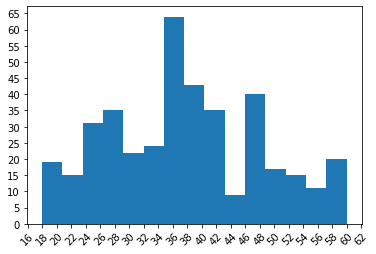

In [153]:
# univariate analysis
plt.xticks(range(0,70,2),rotation =45)
plt.yticks(range(0,70,5))
plt.hist(df['Age'], bins =15);

In [154]:
# for the age col, on put the following values at that index

# 2->8 ,3 ->85

In [155]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


In [156]:
df['Age'][2] = 5
df['Age'][3] = 85
#df.iloc[3,2]=85
#df.iloc[2,2]=8
df

C:\Users\Pornima\AppData\Local\Temp/ipykernel_772/1283233238.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'][2] = 5
C:\Users\Pornima\AppData\Local\Temp/ipykernel_772/1283233238.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'][3] = 85


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,5.0,43000.0,0
3,15603246,Female,85.0,57000.0,0
4,15804002,Male,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


In [157]:
#outliers
# IQR method
# boxplot

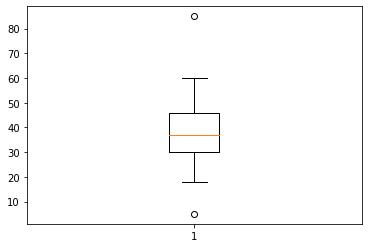

In [158]:
plt.boxplot(df['Age']);


In [159]:
"""
IQR = Q3 - Q1
upper bound= Q3 +1.5 * IQR
LOwer bound = Q1 - 1.5 IQR
""";

In [160]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,5.0,43000.0,0
3,15603246,Female,85.0,57000.0,0
4,15804002,Male,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


{'whiskers': [<matplotlib.lines.Line2D at 0x1d44cb76520>,
 'caps': [<matplotlib.lines.Line2D at 0x1d44cb76c40>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d44cb76190>],
 'medians': [<matplotlib.lines.Line2D at 0x1d44cb823a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1d44cb82730>],
 'means': []}

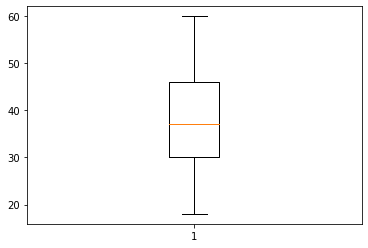

In [164]:
import numpy as np

def remove_outliers(df):
    q1 = np.percentile(df["Age"], 25)
    q3 = np.percentile(df["Age"], 75)

    iqr = q3 - q1

    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr

    df = df[(df["Age"] >= lb) & (df["Age"] <= ub)]

    return df

df = remove_outliers(df)

plt.boxplot(df["Age"])

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672


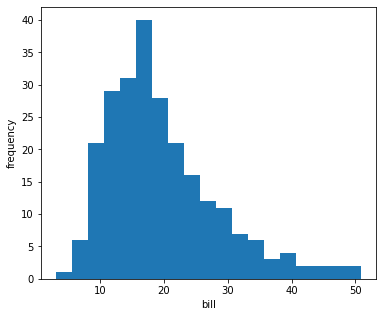

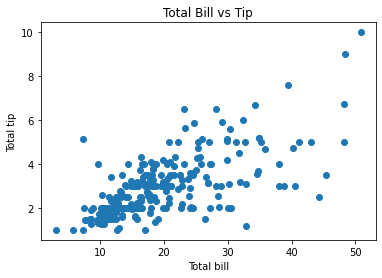

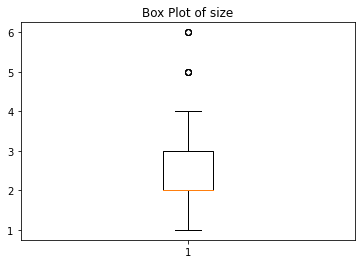

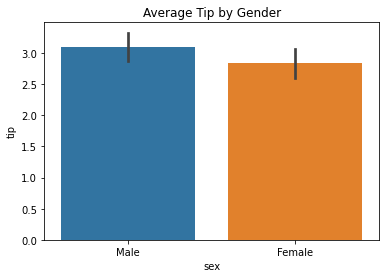

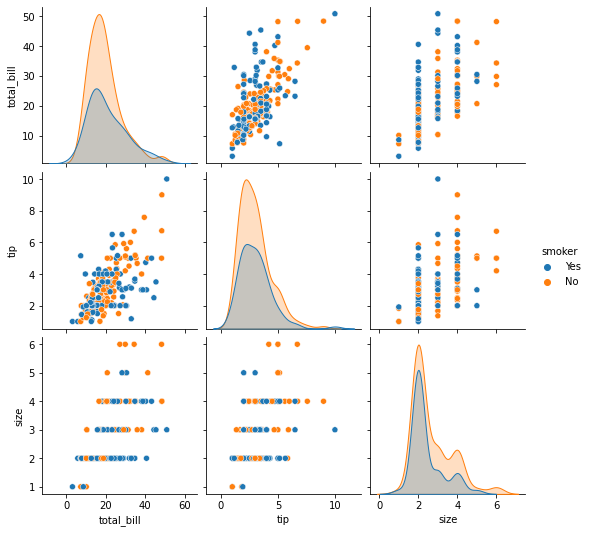

In [149]:
sns.load_dataset("tips")
# Load Dataset
df = sns.load_dataset("tips")
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

# Histrogram
plt.figure(figsize= (6,5))
plt.hist(df['total_bill'],bins = 19)
plt.xlabel("bill")
plt.ylabel("frequency")
plt.show()

# scattter
plt.figure(figsize= (6,4))
plt.scatter(df["total_bill"],df["tip"])
plt.title("Total Bill vs Tip")
plt.xlabel("Total bill")
plt.ylabel("Total tip")

#box plot
plt.figure(figsize= (6,4))
plt.boxplot(df['size'])
plt.title("Box Plot of size")

#bar plot
plt.figure(figsize= (6,4))
plt.title("Average Tip by Gender")
sns.barplot(x='sex',y='tip',data=df)
plt.show()

#pair plot
sns.pairplot(df, hue ='smoker')